[pystran](https://github.com/PetrKryslUCSD/pystran) - Python package for structural analysis with trusses and beams

(C) 2025-2026, Petr Krysl, pkrysl@ucsd.edu

# A 2-D truss sizing optimization: Strength constraints.

Last updated: 06/27/26

## Description

Optimize the cross sectional properties of a truss structure to achieve its 
minimum weight. The bars are manufactured out of square hollow tubes.
Buckling and yielding of the bars is incorporated as constraints.

The bars are grouped into four groups: bottom chord, top chord,
verticals, and diagonals. Each group has its own individual
cross sectional properties.

Objective function: mass of the structure. The design variables are the 
inner dimension of the opening in the tube and thickness of the wall for each group of bars.

Constraints: (1) limit on maximum deflection, and (2) the bars must remain elastic (i.e. prevent yielding),
(3) the bars in compression must not buckle, and (4) the design variables 
are bounded from below so that both the thickness of the wall 
and the inner dimension must be greater than or equal to given lower limits. The dimension constraint is
treated as a lower bound on the design variables.

Mathematically
$$
       x^* = \arg\min f(x)
$$
subject to the constraints
$$
    c_j(x) \ge 0 \; , j=1,4
$$
Note: $f(x)$ is the objective function, whose argument is the vector of the design variables, $x$.


## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)


Imports of the modules and functions that we will need are first.

In [20]:
import context
from math import pi
from numpy import max, ones, zeros, inf, minimum
from pystran import model
from pystran import section
from pystran import truss
from pystran import geometry
from pystran import plots
from scipy.optimize import minimize

We are working in SI(mm) units. Next, we define some useful constants.

The minimum wall thickness is 1.5 mm. The smallest inner dimension is 12 mm.
These constraint will be enforced by the "lower bound" constraint defined below.

In [21]:
INNER_DIM_MIN = 12.0
THICKNESS_MIN = 1.5


Maximum allowed deflection (in millimeters)


In [22]:
MAXIMUM_ALLOWED_DEFLECTION = 10.0


The material properties correspond roughly to steel.


In [23]:
E = 200000
RHO = 8.0e-9
sigy = E / 1000


The magnitude of the vertical (downward) forces in Newton.


In [24]:
W = 6000

Here we define the groups of bars.

In [25]:
group_names = ["bottom_chord", "top_chord", "verticals", "diagonals"]
NGROUPS = len(group_names)
group_bars = [
    [ # bottom_chord
        [1, 2],
        [2, 3],
        [3, 4],
        [4, 5],
    ],
    [ # top_chord
        [6, 7],
        [7, 8],
        [8, 9],
        [9, 10],
    ],
    [ # verticals
        [1, 6],
        [2, 7],
        [3, 8],
        [4, 9],
        [5, 10],
    ],
    [ # diagonals
        [1, 7],
        [3, 9],
        [3, 7],
        [5, 9],
    ]
    ]


The design variables are multiples of these dimensions: The cross sectional area of each group of bars is `_area(dvs[i], dvs[i+NGROUPS])`. 

Initially, all members have cross sections of minimal dimensions. The design variables are nondimensional multipliers of the minimum inner dimension of each group, followed by the nondimensional multipliers of the minimum wall thickness of each group. So the design variables will have to assume values greater than one. The design variables start 
at the value of 1.0. In other words, the inner dimension of the tube is the smallest allowed, and the thickness of the tube wall is also the minimum allowed.


In [26]:
dvs0 = ones(2 * NGROUPS)


The functions to calculate the area of a bar and its moment of area use the  nondimensional values of the design variables, the first for the inner dimension and the second for the wall thickness, to calculate the real radius and wall thickness, and then the area.

In [27]:
def _area(nd, nt):
    d = INNER_DIM_MIN * nd
    t = THICKNESS_MIN * nt
    return (d + 2*t)**2 - d**2 

def _second_moment(nd, nt):
    d = INNER_DIM_MIN * nd
    t = THICKNESS_MIN * nt
    return ((d + 2*t)**4 - d**4) / 12

This function defines the `pystran` model of the structure, based on the values of the
design variables, `dvs`.  Note that the section "name" is the group number `g`. We will use this information in the function `solve`. In anticipation of the need to calculate the Euler buckling force for each member, we also store in the section information the second moment of area as `"I"`.


In [28]:
def truss_model(dvs):
    m = model.create(2)
    freedoms = m['freedoms']
    model.add_joint(m, 1, [-6000, -2500])
    model.add_joint(m, 2, [-3000, -2500])
    model.add_joint(m, 3, [0, -2500])
    model.add_joint(m, 4, [3000, -2500])
    model.add_joint(m, 5, [6000, -2500])
    model.add_joint(m, 6, [-6000, 0])
    model.add_joint(m, 7, [-3000, 0])
    model.add_joint(m, 8, [0, 0])
    model.add_joint(m, 9, [3000, 0])
    model.add_joint(m, 10, [6000, 0])
    model.add_support(m["joints"][1], freedoms.U2)
    model.add_support(m["joints"][5], freedoms.U2)
    model.add_support(m["joints"][8], freedoms.U1)
    model.add_load(m["joints"][2], freedoms.U2, -W)
    model.add_load(m["joints"][3], freedoms.U2, -W)
    model.add_load(m["joints"][4], freedoms.U2, -W)
    for g in range(NGROUPS):
        s = section.truss_section(g, E=E, A=_area(dvs[g], dvs[g+NGROUPS]), rho=RHO)
        s['I'] = _second_moment(dvs[g], dvs[g+NGROUPS])
        for k, c in enumerate(group_bars[g]):
            model.add_truss_member(m, f"{group_names[g]}_{k}", c, s)
    return m

At this point we can display the initial structure: members, joints, applied forces, and supports.


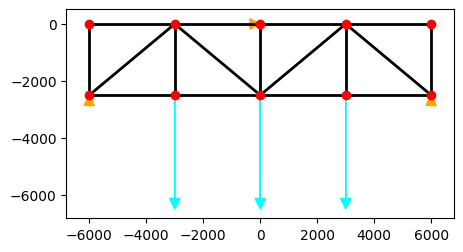

In [29]:
m = truss_model(dvs0)
plots.setup(m)
plots.plot_members(m)
plots.plot_joints(m)
plots.plot_applied_forces(m)
plots.plot_translation_supports(m)
plots.show(m)

The following calculates the total volume of all 
the members of the structure. We can use it to evaluate 
the total mass of the structure. 


In [30]:
mass = RHO * model.volume(m)
print('Initial mass = ', 1000 * mass, ' [kg]')

Initial mass =  33.77408357997502  [kg]


The helper function `solve` is defined to compute the design 
responses (`drs`). Static response of the structure is computed. 

For each member group we compute an array of buckling and yielding constraints.
The buckling constraint is that the force in the bar, $F$, must be greater or equal to $-F_{Euler}=-\pi^2 EI/h^2$:
$$
F \ge -F_{Euler}
$$
This may be converted to a nondimensional form
$$
F /F_{Euler}+1  \ge 0
$$
The yielding constraint may be written in terms of the axial stress (including both yielding in tension and yielding in compression)
$$
|\sigma|\le \sigma_y
$$
This can be rewritten in nondimensional form
$$
1-|\sigma|/\sigma_y\ge 0
$$
Note that the design response for the deflection is just the maximum deflection, while the design responses for the buckling and yielding are already in the form of an array of nondimensionalized constraints.

The design 
responses are the mass of the structure,  the maximum displacement magnitude, and arrays of the buckling and yielding constraints. The design responses are returned as a tuple.

In [31]:
def solve(dvs):
    m = truss_model(dvs)
    model.number_dofs(m)
    model.solve_statics(m)
    buckling = zeros(NGROUPS) + inf
    yielding = zeros(NGROUPS) + inf
    for member in m["truss_members"].values():
        c = member["connectivity"]
        i, j = m["joints"][c[0]], m["joints"][c[1]]
        sect = member["section"]
        A = sect['A']
        I = sect['I']
        _, _, h = geometry.member_2d_geometry(i, j)
        F_eul = pi**2 * E * I / h**2
        F = truss.truss_axial_force(member, i, j, 0.0)
        g = sect['name']
        buckling[g] = minimum(buckling[g], F / F_eul + 1)
        sig = F / A
        yielding[g] = minimum(yielding[g], 1 - abs(sig / sigy))
    drs = (
        RHO * model.volume(m),
        max(abs(m["U"])),
        buckling,
        yielding
    )
    return drs

Now we can report on the performance of the structure 
as originally designed.


In [32]:
drs = solve(dvs0)
initial_mass = drs[0]
initial_max_deflection = drs[1]
initial_buckling = drs[2]
initial_yielding = drs[3]
print("\nInitial structure")
print("-----------------")
print("Initial Design Variables: ", dvs0)
print("Mass: ", 1000 * initial_mass, ' [kg]')
print("Initial largest deflection: ", initial_max_deflection, '[mm]')
print("Initial buckling: ", initial_buckling)
print("Initial yielding: ", initial_yielding)



Initial structure
-----------------
Initial Design Variables:  [1. 1. 1. 1. 1. 1. 1. 1.]
Mass:  33.77408357997502  [kg]
Initial largest deflection:  18.25815155896749 [mm]
Initial buckling:  [ 20.76998705 -25.35998274   1.         -42.60611404]
Initial yielding:  [0.33333333 0.11111111 0.62962963 0.13219448]


Note that the initial structural design leads to buckling in the top chord and in the diagonals. The initial design is therefore infeasible as it violates constraints.

At this point we embark on the optimization. The objective 
function and the constraints need to be defined. 

In [33]:
# Objective function is the normalized mass.
def objective(dvs):
    drs = solve(dvs)
    return drs[0] / initial_mass

Define a constraint on the maximum deflection.  The constraint here is on the maximum deflection, $(u_{max}-\max u)/u_{max}\ge 0$: Here $u_{max}$=`MAXIMUM_ALLOWED_DEFLECTION`. 

Furthermore, define constraint functions for buckling and yielding.

In [34]:
def constrain_deflection(dvs):
    drs = solve(dvs)
    max_deflection = drs[1]
    return (MAXIMUM_ALLOWED_DEFLECTION - max_deflection) / MAXIMUM_ALLOWED_DEFLECTION

def constrain_buckling(dvs):
    drs = solve(dvs)
    return drs[2]

def constrain_yielding(dvs):
    drs = solve(dvs)
    return drs[3]

cons = [
    {"type": "ineq", "fun": constrain_deflection},
    {"type": "ineq", "fun": constrain_buckling},
    {"type": "ineq", "fun": constrain_yielding},
]

The function `constrain_deflection` is used to define an inequality constraint. All such constraints are collected in the list `cons`.




Define lower bounds for the design variables. There are no upper bounds (the `None`).


In [35]:
bounds = [(1.0, None) for _ in range(NGROUPS)] + [(1.0, None) for _ in range(NGROUPS)]

Invoke the optimization function. 


In [36]:
solution = minimize(
    objective,
    dvs0,
    method="SLSQP",
    bounds=bounds,
    constraints=cons,
    options={"ftol": 1e-7, "maxiter": 1000, "disp": True},
)

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2.2166137123914793
            Iterations: 10
            Function evaluations: 90
            Gradient evaluations: 10


Retrieve the values of the design variables from the solution, and compute the design responses
for the optimal design variables.

In [37]:
dvs = solution.x
drs = solve(dvs)

 Now report the characteristics of the optimized structure. The maximum deflection constraint is not active. The yielding constraints are not active. Two of the buckling constraints are active.

In [38]:
drs = solve(dvs)
opt_mass = drs[0]
opt_max_deflection = drs[1]
opt_buckling = drs[2]
opt_yielding = drs[3]
print("\nOptimized structure")
print("-----------------")
print("Optimized Design Variables: ", dvs)
print("Mass: ", 1000 * opt_mass, ' [kg]')
print("Optimized largest deflection: ", opt_max_deflection, '[mm]')
print("Optimized buckling: ", opt_buckling)
print("Optimized yielding: ", opt_yielding)


Optimized structure
-----------------
Optimized Design Variables:  [1.         3.23529179 1.         3.84967376 1.         1.
 1.         1.        ]
Mass:  74.86409678682854  [kg]
Optimized largest deflection:  8.940425098606923 [mm]
Optimized buckling:  [ 2.07699871e+01  4.34097203e-14  1.00000000e+00 -7.83817455e-14]
Optimized yielding:  [0.33333333 0.7024068  0.62962963 0.7543745 ]


The following visualization provides a graphical assessment of the optimized structure: bars with large cross sectional area are shown with thick lines, and conversely bars whose cross sectional area is small are thin.

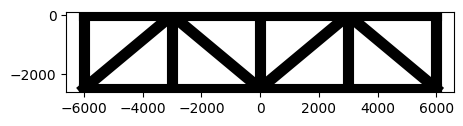

In [39]:
plots.setup(m)
plots.plot_members(m, min_linewidth=1, max_linewidth=8)
plots.show(m) 

Optimized dimensions in mm:


In [41]:
for g in range(NGROUPS):
    print(f'Group {g}: ', f' Inner dimension {INNER_DIM_MIN * dvs[g]},', f' Wall thickness {THICKNESS_MIN * dvs[g+NGROUPS]}') 

Group 0:   Inner dimension 12.0,  Wall thickness 1.5
Group 1:   Inner dimension 38.82350143441433,  Wall thickness 1.5000000000000007
Group 2:   Inner dimension 12.0,  Wall thickness 1.5
Group 3:   Inner dimension 46.196085065261926,  Wall thickness 1.5000000000000004


## Conclusions

In order to satisfy all constraints, the mass of the structure during optimization actually increased.